# Analyzing federal-government articles, 1920-1940

Source: `metaphor/output/filtered_articles_1920_1940.parquet` (1,253,905 articles, each mentioning
**federal / administration / government / new deal / the feds**, 1920-1940).

**Goals**
1. **Describe the corpus** — distributions over time, state, newspaper, article length, and keywords.
2. **Characterize the content** — what these articles say about federal government / policy, via
   TF-IDF term analysis and topic modeling (NMF primary, LDA for comparison).

**Caveats**
- Text is **OCR'd** historical print: noisy. We mitigate with alpha-only cleaning, a 3+ char token
  rule, and a document-frequency floor (`min_df`) that drops rare OCR garbage.
- Every article contains a government keyword **by construction**, so `government/federal/
  administration/new/deal/feds` are added to the stopword list — otherwise they'd dominate every
  topic. Topics therefore reflect *what about* government is discussed.

In [1]:
import os, re, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import NMF, LatentDirichletAllocation
from nltk.corpus import stopwords

%matplotlib inline
warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
pd.set_option("display.max_colwidth", 120)

SRC      = "/kellogg/proj/dashun/ruipan/fame/metaphor/data/filtered_articles_1920_1940.parquet"
OUT_DIR  = "/kellogg/proj/dashun/ruipan/fame/metaphor/output/analysis"
os.makedirs(OUT_DIR, exist_ok=True)

SAMPLE_SIZE  = 100_000   # docs used for topic modeling (metadata stats use ALL rows)
N_TOPICS     = 12
N_TOP_WORDS  = 12
RANDOM_STATE = 42

df = pd.read_parquet(SRC)
print(f"Loaded {len(df):,} articles x {df.shape[1]} columns")
print("columns:", list(df.columns))

Loaded 1,253,905 articles x 13 columns
columns: ['article_id', 'newspaper_name', 'edition', 'date', 'year', 'page', 'headline', 'byline', 'article', 'word_count', 'state', 'matched_keywords', 'match_count']


## 1. Corpus description (all 1.25M articles)

In [2]:
print("OVERVIEW")
print(f"  articles         : {len(df):,}")
print(f"  year range       : {int(df.year.min())}-{int(df.year.max())}")
print(f"  distinct papers  : {df.newspaper_name.nunique():,}")
print(f"  distinct states  : {df.state.nunique()}   (null state: {df.state.isna().mean():.1%})")
print("\nword_count summary:");  print(df.word_count.describe().round(1).to_string())
print("\nmatch_count summary:"); print(df.match_count.describe().round(2).to_string())

OVERVIEW
  articles         : 1,253,905
  year range       : 1920-1940
  distinct papers  : 438
  distinct states  : 41   (null state: 0.5%)

word_count summary:
count    1253905.0
mean         277.2
std          222.4
min            1.0
25%          108.0
50%          210.0
75%          388.0
max         1624.0

match_count summary:


count    1253905.00
mean           1.84
std            1.61
min            1.00
25%            1.00
50%            1.00
75%            2.00
max           38.00


### 1a. Articles per year

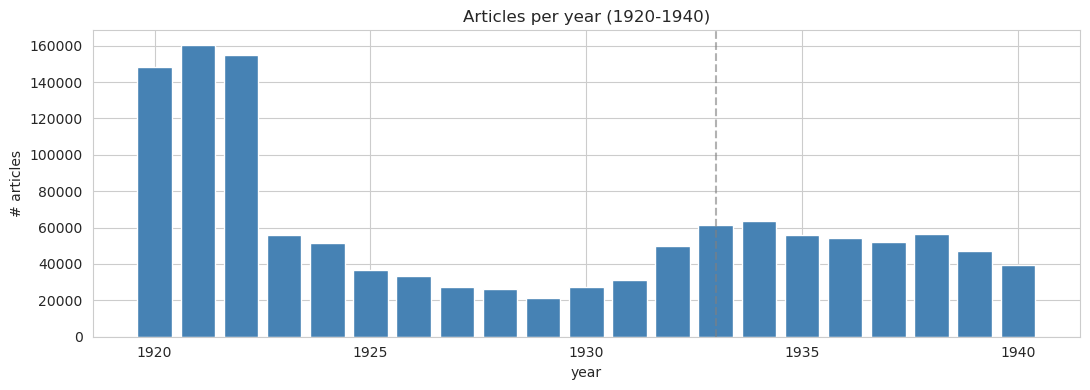

year,1920,1921,1922,1923,1924,1925,1926,1927,1928,1929,...,1931,1932,1933,1934,1935,1936,1937,1938,1939,1940
n_articles,148167,160459,154902,56053,51329,36679,33274,27340,26008,21332,...,30994,49654,61421,63686,55824,54296,52150,56556,47172,39509


In [3]:
by_year = df.year.value_counts().sort_index()
fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(by_year.index, by_year.values, color="steelblue")
ax.set(title="Articles per year (1920-1940)", xlabel="year", ylabel="# articles")
ax.axvline(1933, ls="--", c="grey", alpha=.6)
plt.tight_layout(); plt.show()
display(by_year.rename("n_articles").to_frame().T)

### 1b. By state

states represented: 41  |  articles with null state: 6,216


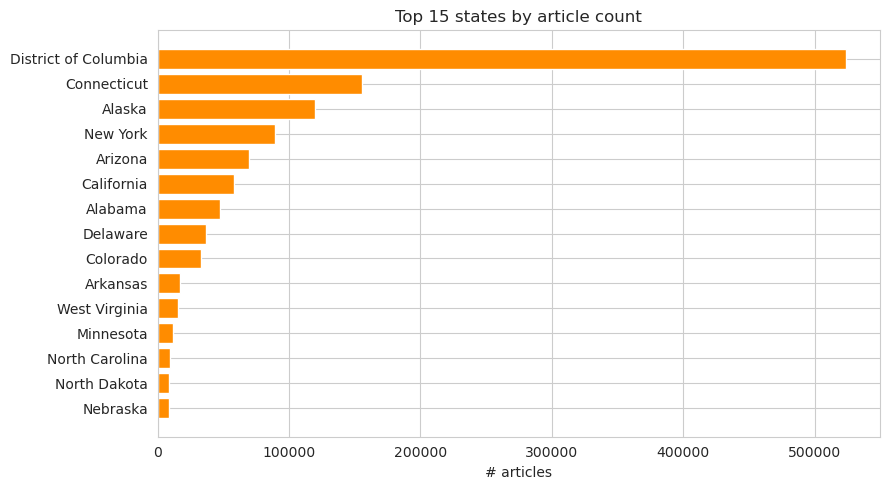

In [4]:
by_state = df.state.value_counts()
print(f"states represented: {by_state.size}  |  articles with null state: {df.state.isna().sum():,}")
top_state = by_state.head(15)[::-1]
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(top_state.index, top_state.values, color="darkorange")
ax.set(title="Top 15 states by article count", xlabel="# articles")
plt.tight_layout(); plt.show()

### 1c. By newspaper

distinct newspapers: 438


,n_articles
newspaper_name,
Evening star.,394073
The Washington times.,102842
The Waterbury Democrat.,63886
Imperial Valley press.,57939
New Britain herald.,54701
The Birmingham age-herald.,47421
New-York tribune.,46080
The Daily Alaska empire.,40360
The New York herald.,38184


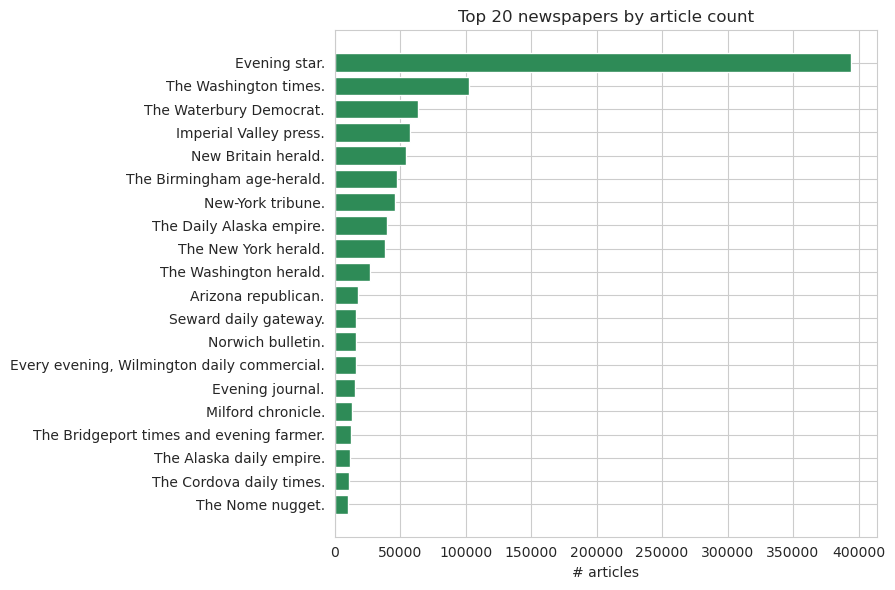

In [5]:
by_paper = df.newspaper_name.value_counts()
print(f"distinct newspapers: {by_paper.size:,}")
display(by_paper.head(20).rename("n_articles").to_frame())
tp = by_paper.head(20)[::-1]
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(tp.index, tp.values, color="seagreen")
ax.set(title="Top 20 newspapers by article count", xlabel="# articles")
plt.tight_layout(); plt.show()

### 1d. Article length

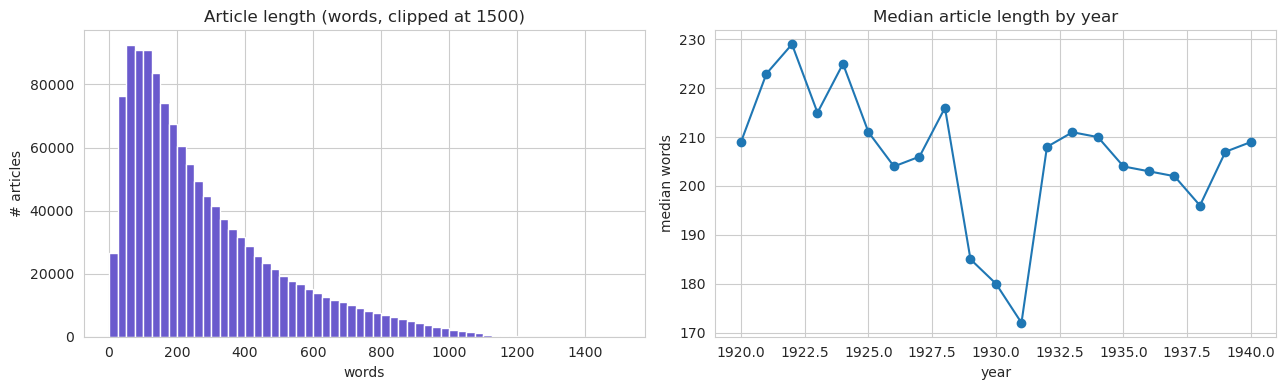

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(df.word_count.clip(upper=1500), bins=60, color="slateblue")
axes[0].set(title="Article length (words, clipped at 1500)", xlabel="words", ylabel="# articles")
med = df.groupby("year").word_count.median()
axes[1].plot(med.index, med.values, marker="o")
axes[1].set(title="Median article length by year", xlabel="year", ylabel="median words")
plt.tight_layout(); plt.show()

### 1e. Keywords: prevalence, combinations, and trend over time

Articles containing each keyword (a doc may match several):


,n_articles,pct_of_corpus
matched_keywords,,
government,789298,62.9
federal,441954,35.2
administration,221145,17.6
new deal,41429,3.3
the feds,218,0.0



Top matched-keyword combinations:


,n_articles
matched_keywords,
"(government,)",604134
"(federal,)",284184
"(administration,)",132487
"(federal, government)",113976
"(administration, government)",41429
"(new deal,)",20629
"(federal, administration)",18589
"(federal, administration, government)",17463
"(administration, new deal)",5186


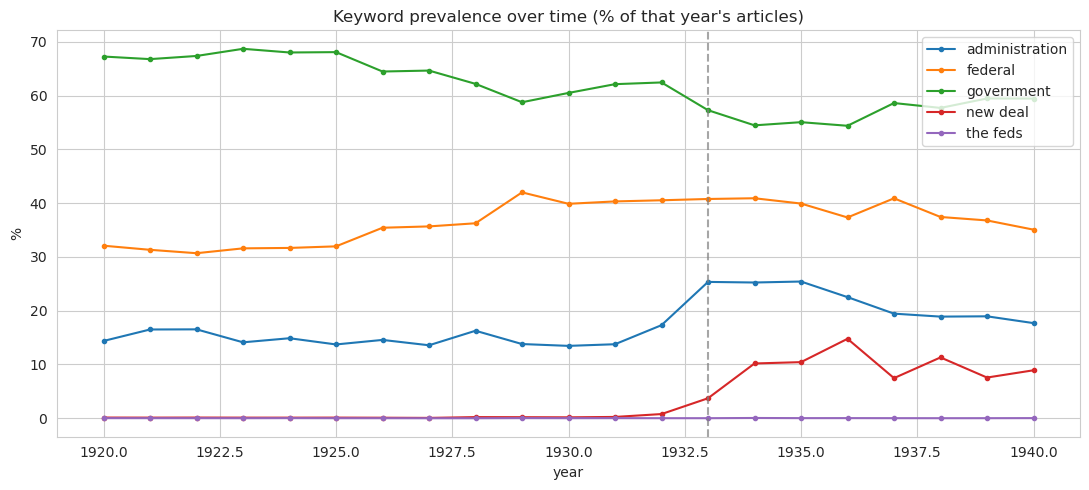

In [7]:
kw_counts = df["matched_keywords"].explode().value_counts()
print("Articles containing each keyword (a doc may match several):")
display(kw_counts.rename("n_articles").to_frame()
        .assign(pct_of_corpus=lambda d: (d.n_articles / len(df) * 100).round(1)))

print("\nTop matched-keyword combinations:")
display(df["matched_keywords"].map(tuple).value_counts().head(10).rename("n_articles").to_frame())

# prevalence over time (% of each year's articles containing the keyword)
ky = df[["year", "matched_keywords"]].explode("matched_keywords")
kw_year = ky.groupby(["year", "matched_keywords"]).size().unstack(fill_value=0)
share = kw_year.div(df.groupby("year").size(), axis=0) * 100
fig, ax = plt.subplots(figsize=(11, 5))
for k in share.columns:
    ax.plot(share.index, share[k], marker="o", ms=3, label=k)
ax.axvline(1933, ls="--", c="grey", alpha=.7)
ax.set(title="Keyword prevalence over time (% of that year's articles)", xlabel="year", ylabel="%")
ax.legend(); plt.tight_layout(); plt.show()

## 2. Content analysis (stratified ~100k sample)

Topic modeling on a year-stratified random sample for speed; the metadata stats above use all rows.

In [8]:
frac = min(1.0, SAMPLE_SIZE / len(df))
sample = (df.groupby("year", group_keys=False)
            .sample(frac=frac, random_state=RANDOM_STATE)
            .reset_index(drop=True))
print(f"Stratified sample: {len(sample):,} articles (frac={frac:.3f} per year)")

raw = sample["headline"].fillna("") + " " + sample["article"].fillna("")
sample["clean"] = (raw.str.lower()
                      .str.replace(r"[^a-z\s]", " ", regex=True)
                      .str.replace(r"\s+", " ", regex=True)
                      .str.strip())
print("example cleaned text:\n", sample["clean"].iloc[0][:280], "...")

Stratified sample: 99,999 articles (frac=0.080 per year)


example cleaned text:
 i lss co the condition of the peasants prior to the revolution according to official documents appears to be as follows in the u central governments they grow on the average sufficient rye for bread for only days in the year often for only and days one quarter of the people have  ...


In [9]:
base_stop   = set(stopwords.words("english"))
domain_stop = {
    # ubiquitous by construction -> remove so topics show WHAT about government
    "government","governments","governmental","federal","federally","federalism",
    "administration","administrations","new","deal","deals","feds","fed",
    # generic newspaper / OCR boilerplate
    "said","will","would","one","two","three","also","upon","mr","mrs","dr","st","per",
    "today","yesterday","year","years","day","days","time","made","make","many","much",
    "city","county","week","last","first","may","can","now","said","says","told",
}
STOP = sorted(base_stop | domain_stop)
print(f"{len(STOP)} stopwords (nltk english + {len(domain_stop)} domain/boilerplate terms)")

223 stopwords (nltk english + 47 domain/boilerplate terms)


### 2a. Top terms and bigrams (TF-IDF)

TF-IDF matrix: 99,999 docs x 30,000 terms


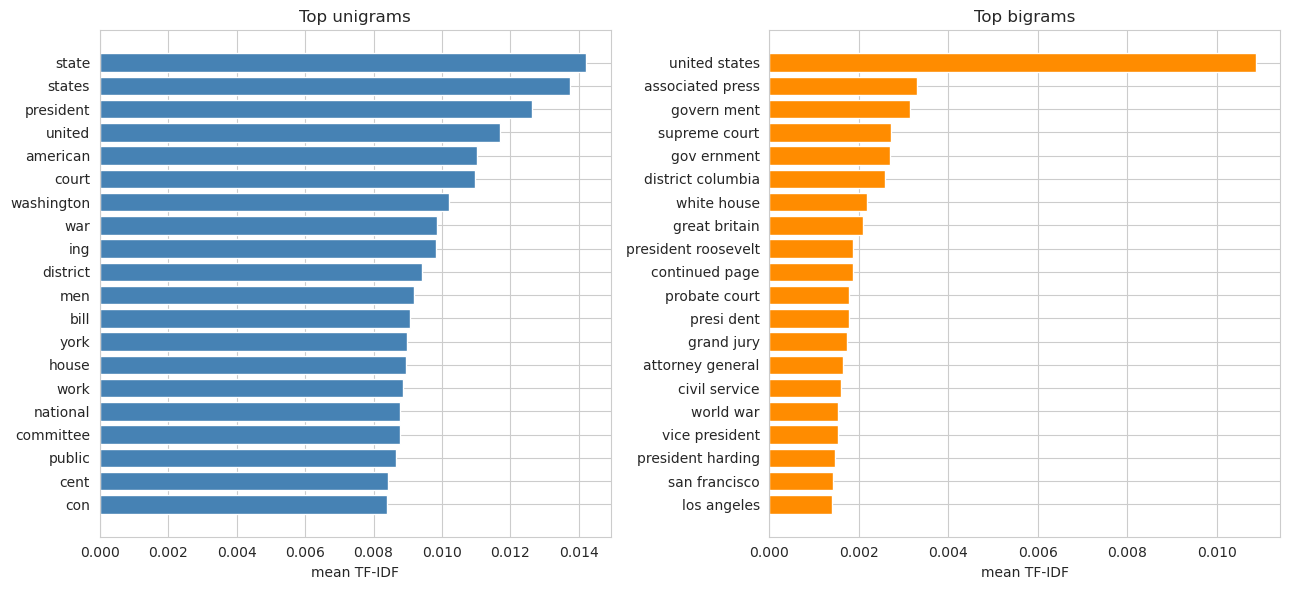

In [10]:
tfidf = TfidfVectorizer(max_features=30000, min_df=20, max_df=0.5, ngram_range=(1, 2),
                        stop_words=STOP, token_pattern=r"(?u)\b[a-z]{3,}\b")
X = tfidf.fit_transform(sample["clean"])
terms = np.array(tfidf.get_feature_names_out())
print(f"TF-IDF matrix: {X.shape[0]:,} docs x {X.shape[1]:,} terms")

mean_tfidf = np.asarray(X.mean(axis=0)).ravel()
order = mean_tfidf.argsort()[::-1]
is_bi = np.array([" " in t for t in terms])
top_uni = [(terms[i], mean_tfidf[i]) for i in order if not is_bi[i]][:20]
top_bi  = [(terms[i], mean_tfidf[i]) for i in order if is_bi[i]][:20]
fig, axes = plt.subplots(1, 2, figsize=(13, 6))
for ax, (title, data, color) in zip(axes,
        [("Top unigrams", top_uni, "steelblue"), ("Top bigrams", top_bi, "darkorange")]):
    labels = [t for t, _ in data][::-1]; vals = [v for _, v in data][::-1]
    ax.barh(labels, vals, color=color); ax.set_title(title); ax.set_xlabel("mean TF-IDF")
plt.tight_layout(); plt.show()

### 2b. NMF topics (primary)

In [11]:
def topic_words(components, vocab, n):
    return [[vocab[i] for i in row.argsort()[::-1][:n]] for row in components]

nmf = NMF(n_components=N_TOPICS, init="nndsvda", random_state=RANDOM_STATE, max_iter=400)
W = nmf.fit_transform(X)
nmf_words = topic_words(nmf.components_, terms, N_TOP_WORDS)

nmf_tbl = pd.DataFrame({f"Topic {t}": ws for t, ws in enumerate(nmf_words)}).T
nmf_tbl.columns = [f"w{i+1}" for i in range(N_TOP_WORDS)]
print("NMF topics (top words):")
display(nmf_tbl)

NMF topics (top words):


,w1,w2,w3,w4,w5,w6,w7,w8,w9,w10,w11,w12
Topic 0,people,men,must,work,business,country,public,every,great,good,man,world
Topic 1,probate,district,columbia,court,district columbia,estate,probate court,deceased,court district,subscriber,notice,letters
Topic 2,market,prices,bonds,cent,stock,points,cotton,issues,wheat,stocks,york,price
Topic 3,british,french,germany,german,france,war,britain,russia,soviet,japanese,treaty,london
Topic 4,miss,school,street,club,home,meeting,washington,church,building,night,john,service
Topic 5,court,judge,jury,case,attorney,liquor,law,trial,justice,prohibition,grand,grand jury
Topic 6,bill,senate,house,committee,senator,congress,measure,passed,session,legislation,bills,amendment
Topic 7,party,president,republican,senator,democratic,roosevelt,state,governor,democrats,election,campaign,political
Topic 8,tax,income,taxes,income tax,cent,revenue,state,pay,treasury,paid,taxation,total
Topic 9,states,united,united states,american,mexico,mexican,washington,president,department,america,secretary,foreign


### 2c. Topic top terms

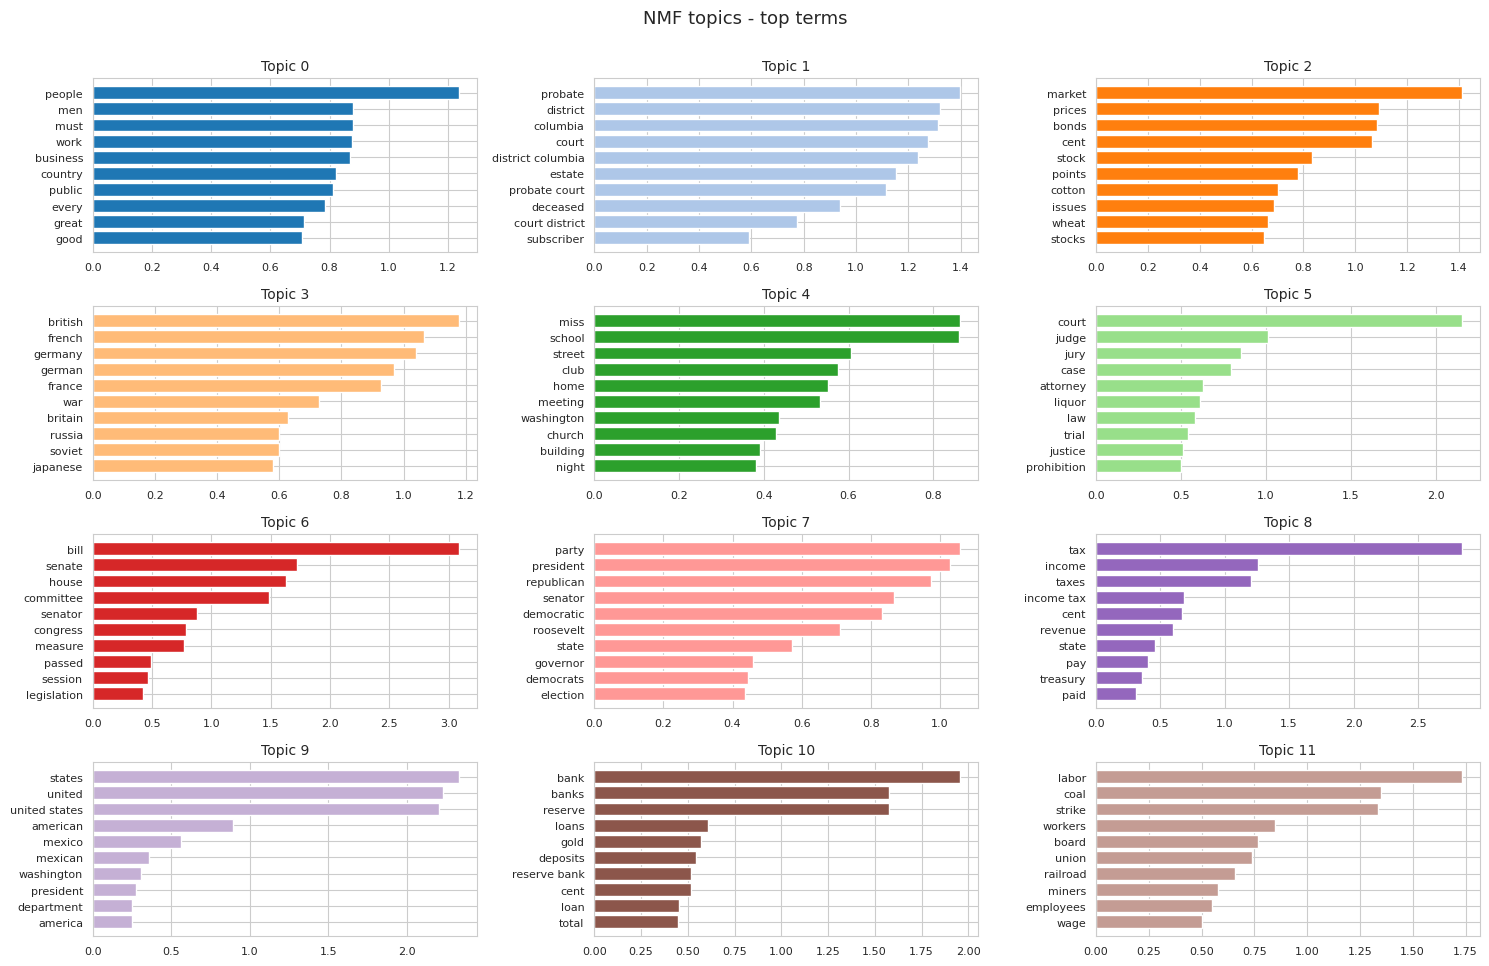

In [12]:
H = nmf.components_
ncol = 3; nrow = int(np.ceil(N_TOPICS / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(5 * ncol, 2.4 * nrow))
for t, ax in enumerate(axes.ravel()):
    if t >= N_TOPICS:
        ax.axis("off"); continue
    idx = H[t].argsort()[::-1][:10]
    words   = [terms[i] for i in idx][::-1]
    weights = [H[t, i]  for i in idx][::-1]
    ax.barh(words, weights, color=plt.cm.tab20(t % 20))
    ax.set_title(f"Topic {t}", fontsize=10)
    ax.tick_params(labelsize=8)
fig.suptitle("NMF topics - top terms", y=1.002, fontsize=13)
plt.tight_layout(); plt.show()

### 2d. Topic prevalence over time

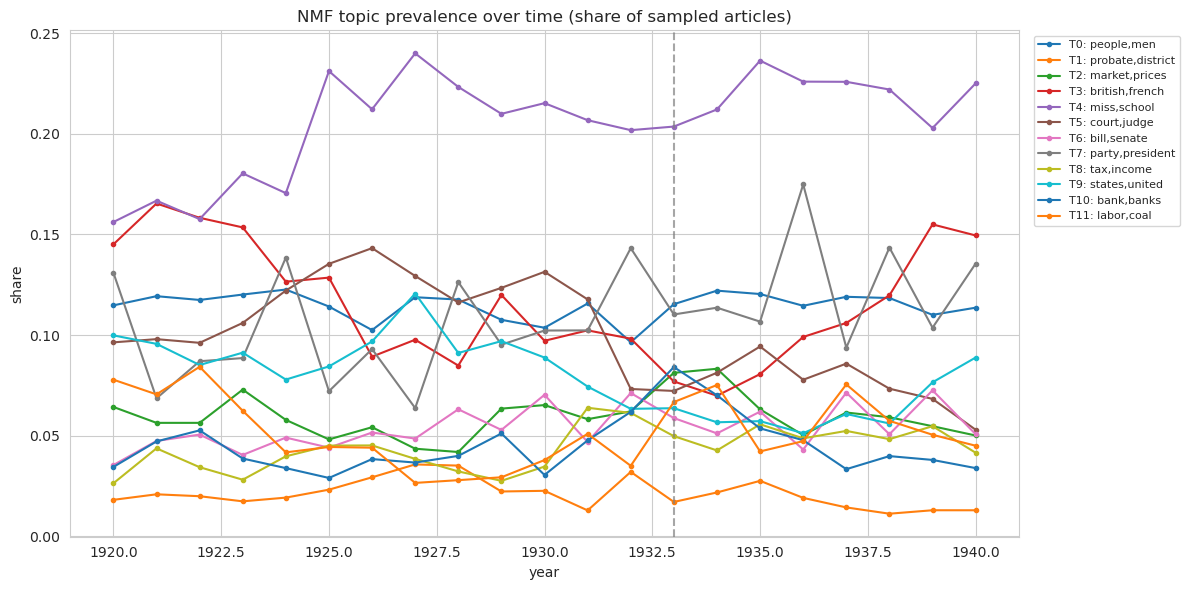

In [13]:
sample["topic"] = W.argmax(axis=1)
prev = sample.groupby(["year", "topic"]).size().unstack(fill_value=0)
prev_share = prev.div(prev.sum(axis=1), axis=0)
fig, ax = plt.subplots(figsize=(12, 6))
for t in range(N_TOPICS):
    if t in prev_share.columns:
        ax.plot(prev_share.index, prev_share[t], marker="o", ms=3,
                label=f"T{t}: " + ",".join(nmf_words[t][:2]))
ax.axvline(1933, ls="--", c="grey", alpha=.7)
ax.set(title="NMF topic prevalence over time (share of sampled articles)",
       xlabel="year", ylabel="share")
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
plt.tight_layout(); plt.show()
prev_share.to_csv(os.path.join(OUT_DIR, "topic_prevalence_by_year.csv"))

### 2e. Representative article per topic

In [14]:
print("Highest-weight article for each NMF topic:\n")
for t in range(N_TOPICS):
    i = W[:, t].argmax(); row = sample.iloc[i]
    print("=" * 92)
    print(f"TOPIC {t} [" + ", ".join(nmf_words[t][:4]) + f"]  ->  "
          f"{row.newspaper_name} | {row.date} | {row.state}")
    print(re.sub(r"\s+", " ", str(row.article))[:460], "...")
    print()

Highest-weight article for each NMF topic:

TOPIC 0 [people, men, must, work]  ->  Evening star. | 1933-10-22 | District of Columbia
Hopkins is working under Government orders He has lot OF money $500 900 000-money which. according to the Governments understanding i'll voting it, was to be met by the COM munities and States of the country which had resources to draw on. II the Federal Government gave so much the town and State should match 1t II possible. II that fine plan could be carried out fully there would be in charge of the public relief agencies of this country, Federal and loca ...

TOPIC 1 [probate, district, columbia, court]  ->  Evening star. | 1933-02-18 | District of Columbia
SUPREME COURT OF THE DISTRICT of Columbia, holding Probate Court No 444Tfa Administration is to give notice that the subscriber. of the District of Columbia, has obtained from the Probate Court of the District of Columbia letters OF administration on the estate Of Mary. j. late of the District Of Col

### 2f. LDA topics (secondary, for comparison)

In [15]:
cv = CountVectorizer(max_features=30000, min_df=20, max_df=0.5, ngram_range=(1, 1),
                     stop_words=STOP, token_pattern=r"(?u)\b[a-z]{3,}\b")
Xc = cv.fit_transform(sample["clean"])
cv_terms = np.array(cv.get_feature_names_out())
lda = LatentDirichletAllocation(n_components=N_TOPICS, random_state=RANDOM_STATE,
                                learning_method="online", batch_size=2048, max_iter=10)
lda.fit(Xc)
lda_words = topic_words(lda.components_, cv_terms, N_TOP_WORDS)
lda_tbl = pd.DataFrame({f"Topic {t}": ws for t, ws in enumerate(lda_words)}).T
lda_tbl.columns = [f"w{i+1}" for i in range(N_TOP_WORDS)]
print("LDA topics (top words):")
display(lda_tbl)

LDA topics (top words):


,w1,w2,w3,w4,w5,w6,w7,w8,w9,w10,w11,w12
Topic 0,court,case,police,law,attorney,judge,liquor,states,jury,prohibition,justice,men
Topic 1,tax,bill,service,board,committee,work,public,labor,district,relief,pay,state
Topic 2,court,estate,district,state,shall,probate,notice,property,law,columbia,irish,deceased
Topic 3,states,united,american,president,con,congress,people,conference,power,must,country,national
Topic 4,cent,bank,market,stock,banks,bonds,york,prices,reserve,gold,business,loans
Topic 5,senator,president,senate,republican,house,party,state,roosevelt,democratic,bill,committee,governor
Topic 6,people,man,men,every,great,country,good,old,world,life,get,work
Topic 7,coal,room,rooms,district,ave,bath,house,large,home,miners,company,columbia
Topic 8,united,states,american,japanese,mexico,japan,china,air,navy,chinese,radio,naval
Topic 9,miss,school,washington,president,national,meeting,street,club,john,home,held,george


### 2g. Save derived tables

In [16]:
nmf_tbl.to_csv(os.path.join(OUT_DIR, "topic_terms_nmf.csv"))
lda_tbl.to_csv(os.path.join(OUT_DIR, "topic_terms_lda.csv"))
print("saved to", OUT_DIR)
for f in sorted(os.listdir(OUT_DIR)):
    print("  -", f)

saved to /kellogg/proj/dashun/ruipan/fame/metaphor/output/analysis
  - topic_prevalence_by_year.csv
  - topic_terms_lda.csv
  - topic_terms_nmf.csv


## 3. Takeaways

In [17]:
print("WHAT THE 1920-1940 FEDERAL-GOVERNMENT ARTICLES DISCUSS\n")
print("NMF topic labels (top-3 terms):")
for t in range(N_TOPICS):
    print(f"  Topic {t:2d}: " + ", ".join(nmf_words[t][:3]))

early = sample[sample.year <= 1932]["topic"].value_counts(normalize=True)
late  = sample[sample.year >= 1933]["topic"].value_counts(normalize=True)
delta = (late.reindex(range(N_TOPICS), fill_value=0)
         - early.reindex(range(N_TOPICS), fill_value=0)).sort_values(ascending=False)
print("\nTopics that GREW most in 1933-1940 vs 1920-1932 (New Deal era):")
for t in delta.head(3).index:
    print(f"  +{delta[t]*100:4.1f} pp  Topic {t}: " + ", ".join(nmf_words[t][:4]))
print("\nTopics that SHRANK most:")
for t in delta.tail(3).index:
    print(f"  {delta[t]*100:5.1f} pp  Topic {t}: " + ", ".join(nmf_words[t][:4]))

WHAT THE 1920-1940 FEDERAL-GOVERNMENT ARTICLES DISCUSS

NMF topic labels (top-3 terms):
  Topic  0: people, men, must
  Topic  1: probate, district, columbia
  Topic  2: market, prices, bonds
  Topic  3: british, french, germany
  Topic  4: miss, school, street
  Topic  5: court, judge, jury
  Topic  6: bill, senate, house
  Topic  7: party, president, republican
  Topic  8: tax, income, taxes
  Topic  9: states, united, united states
  Topic 10: bank, banks, reserve
  Topic 11: labor, coal, strike



Topics that GREW most in 1933-1940 vs 1920-1932 (New Deal era):
  + 3.9 pp  Topic 4: miss, school, street, club
  + 2.3 pp  Topic 7: party, president, republican, senator
  + 1.1 pp  Topic 8: tax, income, taxes, income tax

Topics that SHRANK most:
   -2.8 pp  Topic 9: states, united, united states, american
   -2.9 pp  Topic 5: court, judge, jury, case
   -3.4 pp  Topic 3: british, french, germany, german


---
**Notes**
- Topics are data-driven; the labels above are the top terms, not hand-curated themes. Skim §2b/2c
  and the representative articles in §2e to name them (e.g. relief/works programs, taxation/budget,
  elections/parties, foreign/war, local government).
- Tunable knobs in the setup cell: `SAMPLE_SIZE`, `N_TOPICS`, `N_TOP_WORDS`. To analyze the **full**
  corpus, set `SAMPLE_SIZE = len(df)` (slower). To sharpen topics, raise `min_df` or extend the
  domain stopword set.
- NMF (on TF-IDF) is the primary model; LDA (§2f) is a cross-check — compare which themes are stable
  across both.